# Check the CSV dataset before training:
-> check the row, col, dtypes, etc.

In [3]:
import pandas as pd
import chess
import torch
from torch.utils.data import Dataset

df = pd.read_csv("./dataset/Lichess_clean_2016_80k_games.csv")
print("Rows:", len(df))
df.head()

Rows: 79788


,White,Black,Result,ECO,Opening,Moves,MoveCount,WhiteWin,BlackWin,Draw
0,Mescalero25,fialho,1-0,C00,French Defense: King's Indian Attack,e4 e6 d3 d5 Nd2 dxe4 Nxe4 b6 g3 Bb7 Bg2 Be7 Nf...,77,1,0,0
1,theosis101,sebafreire,1-0,A43,Old Benoni Defense,d4 c5 c4 cxd4 Nf3 Nc6 e3 e6 exd4 Nf6 Nc3 d5 cx...,55,1,0,0
2,BrettDale,Viriskensoshir,0-1,B72,"Sicilian Defense: Dragon, Classical Attack",e4 c5 Nf3 d6 d4 cxd4 Nxd4 Nf6 Nc3 g6 Be2 Bg7 B...,54,0,1,0
3,borgs,IntiTupac,0-1,A13,English Opening: Agincourt Defense #3,c4 e6 Nf3 a6 g3 g6 Bg2 Bg7 O-O Ne7 d4 d5 cxd5 ...,92,0,1,0
4,Aquariano,Moszkowski,1-0,A40,Englund Gambit Complex: Soller Gambit,d4 e5 dxe5 f6 exf6 Nxf6 a3 Bc5 e3 O-O Nc3 a6 B...,119,1,0,0


# Dataset → (board → next_move)

# Encode moves (targets)

# Model Checking
1. Accuracy 
2. Recal 
3. 

📊 Loaded dataset: 79788 games
0/10000 games processed...
200/10000 games processed...
400/10000 games processed...
600/10000 games processed...
800/10000 games processed...
1000/10000 games processed...
1200/10000 games processed...
1400/10000 games processed...
1600/10000 games processed...
1800/10000 games processed...
2000/10000 games processed...
2200/10000 games processed...
2400/10000 games processed...
2600/10000 games processed...
2800/10000 games processed...
3000/10000 games processed...
3200/10000 games processed...
3400/10000 games processed...
3600/10000 games processed...
3800/10000 games processed...
4000/10000 games processed...
4200/10000 games processed...
4400/10000 games processed...
4600/10000 games processed...
4800/10000 games processed...
5000/10000 games processed...
5200/10000 games processed...
5400/10000 games processed...
5600/10000 games processed...
5800/10000 games processed...
6000/10000 games processed...
6200/10000 games processed...
6400/10000 games 

C:\Users\mdala\AppData\Local\Temp\ipykernel_27904\2662295505.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(targets, dtype=torch.long, device=device)
C:\Users\mdala\AppData\Local\Temp\ipykernel_27904\2662295505.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(targets, dtype=torch.long, device=device)


Epoch 1/10 | Train Loss: 7.0680 | Val Accuracy: 6.33% | Time: 0.2 min
Epoch 2/10 | Train Loss: 6.7180 | Val Accuracy: 7.05% | Time: 0.2 min
Epoch 3/10 | Train Loss: 6.5951 | Val Accuracy: 7.99% | Time: 0.2 min
Epoch 4/10 | Train Loss: 6.5361 | Val Accuracy: 8.00% | Time: 0.2 min
Epoch 5/10 | Train Loss: 6.5061 | Val Accuracy: 8.13% | Time: 0.2 min
Epoch 6/10 | Train Loss: 6.4800 | Val Accuracy: 8.23% | Time: 0.2 min
Epoch 7/10 | Train Loss: 6.4622 | Val Accuracy: 8.20% | Time: 0.2 min
Epoch 8/10 | Train Loss: 6.4528 | Val Accuracy: 8.32% | Time: 0.2 min
Epoch 9/10 | Train Loss: 6.4440 | Val Accuracy: 8.39% | Time: 0.2 min
Epoch 10/10 | Train Loss: 6.4367 | Val Accuracy: 8.42% | Time: 0.2 min

✅ Model saved at: c:\Users\mdala\OneDrive\Desktop\Semester6\AI Project\lichess-bot\training_model\model\chess_model_v4.pt


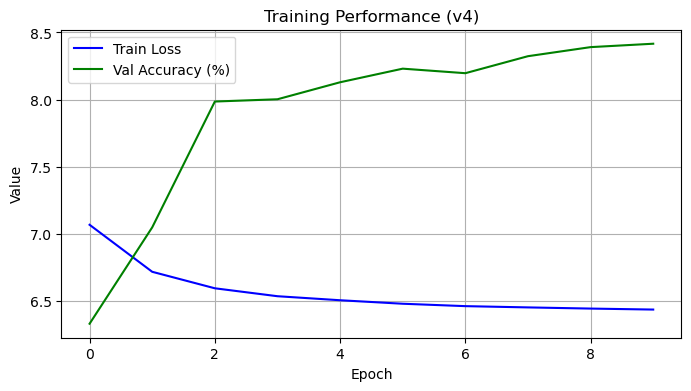

In [27]:
# =============================================
# ♟️ Chess CNN Training v4 (Optimized for Accuracy)
# =============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split
import pandas as pd
import time
import os
from pathlib import Path
import matplotlib.pyplot as plt

from chess_dataset import ChessDataset, move_to_idx
from chess_cnn import ChessCNN

# === Load Dataset ===
try:
    base_dir = Path(__file__).resolve().parent
except NameError:
    base_dir = Path(os.getcwd())

data_path = base_dir / "dataset" / "Lichess_clean_2016_80k_games.csv"
df = pd.read_csv(data_path)
print(f"📊 Loaded dataset: {len(df)} games")

# === Dataset & Split ===
dataset = ChessDataset(df, max_games=10000)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# === Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training on: {device}")

model = ChessCNN(num_outputs=len(move_to_idx)).to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)
criterion = nn.CrossEntropyLoss()

# === Training ===
epochs = 10
train_losses, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    start = time.time()

    for boards, targets in train_loader:
        boards = boards.to(device)
        targets = torch.tensor(targets, dtype=torch.long, device=device)

        optimizer.zero_grad()
        outputs = model(boards)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step()

    # === Validation phase ===
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for boards, targets in val_loader:
            boards = boards.to(device)
            targets = torch.tensor(targets, dtype=torch.long, device=device)
            outputs = model(boards)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    val_acc = 100 * correct / total
    train_losses.append(avg_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.2f}% | Time: {(time.time()-start)/60:.1f} min")

# === Save Model ===
save_path = base_dir / "model" / "chess_model_v4.pt"
save_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f"\n✅ Model saved at: {save_path}")

# === Plot Performance ===
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(val_accuracies, label="Val Accuracy (%)", color='green')
plt.title("Training Performance (v4)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()






In [28]:

# === Save move_to_idx ===
import pickle
dict_path = base_dir / "model" / "move_to_idx.pkl"
with open(dict_path, "wb") as f:
    pickle.dump(move_to_idx, f)
print(f"✅ move_to_idx dictionary saved at: {dict_path}")

✅ move_to_idx dictionary saved at: c:\Users\mdala\OneDrive\Desktop\Semester6\AI Project\lichess-bot\training_model\model\move_to_idx.pkl
